# House Price Prediction



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('Housing.csv')
df.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Task 1 - Data Loading & Exploration

In [3]:
print('Shape:', df.shape)
print('\nMissing Values:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
print('\nColumns:', df.columns.tolist())

target='price'
features=[col for col in df.columns if col!='price']
print('Target:', target)
print('Features:', features)




Shape: (545, 13)

Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicates: 0

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Target: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


## Task 2 - Data Cleaning

In [6]:
df = df.drop_duplicates()

binary_cols=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col]=df[col].map({'yes':1,'no':0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Task 3 - Model Building

In [7]:
X=df.drop('price',axis=1)
y=df['price']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

lr=LinearRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)

rf=RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

def evaluate(y_true,y_pred,name):
    mae=mean_absolute_error(y_true,y_pred)
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    r2=r2_score(y_true,y_pred)
    print(f'\n{name}')
    print('MAE:',mae)
    print('RMSE:',rmse)
    print('R2:',r2)

evaluate(y_test,lr_pred,'Linear Regression')
evaluate(y_test,rf_pred,'Random Forest')



Linear Regression
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R2: 0.6529242642153186

Random Forest
MAE: 1014947.3230122325
RMSE: 1399769.443949671
R2: 0.6123598247296523


## Task 4 - Visualizations

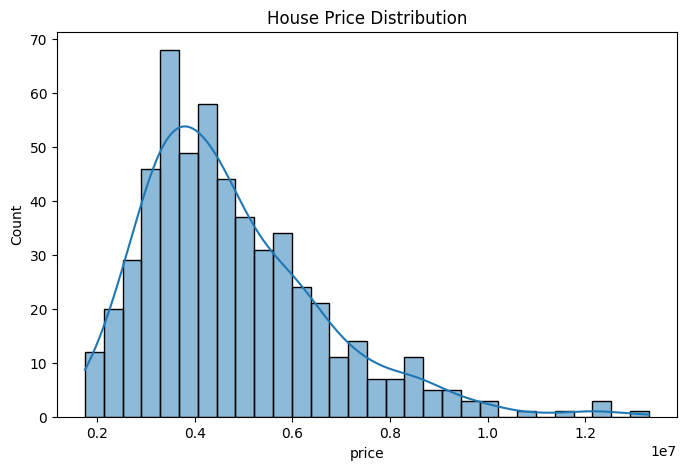

In [8]:
# Chart 1
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('House Price Distribution')
plt.savefig('house_price_distribution.png')
plt.show()


Text(0.5, 1.0, 'Feature Correlation Heatmap')

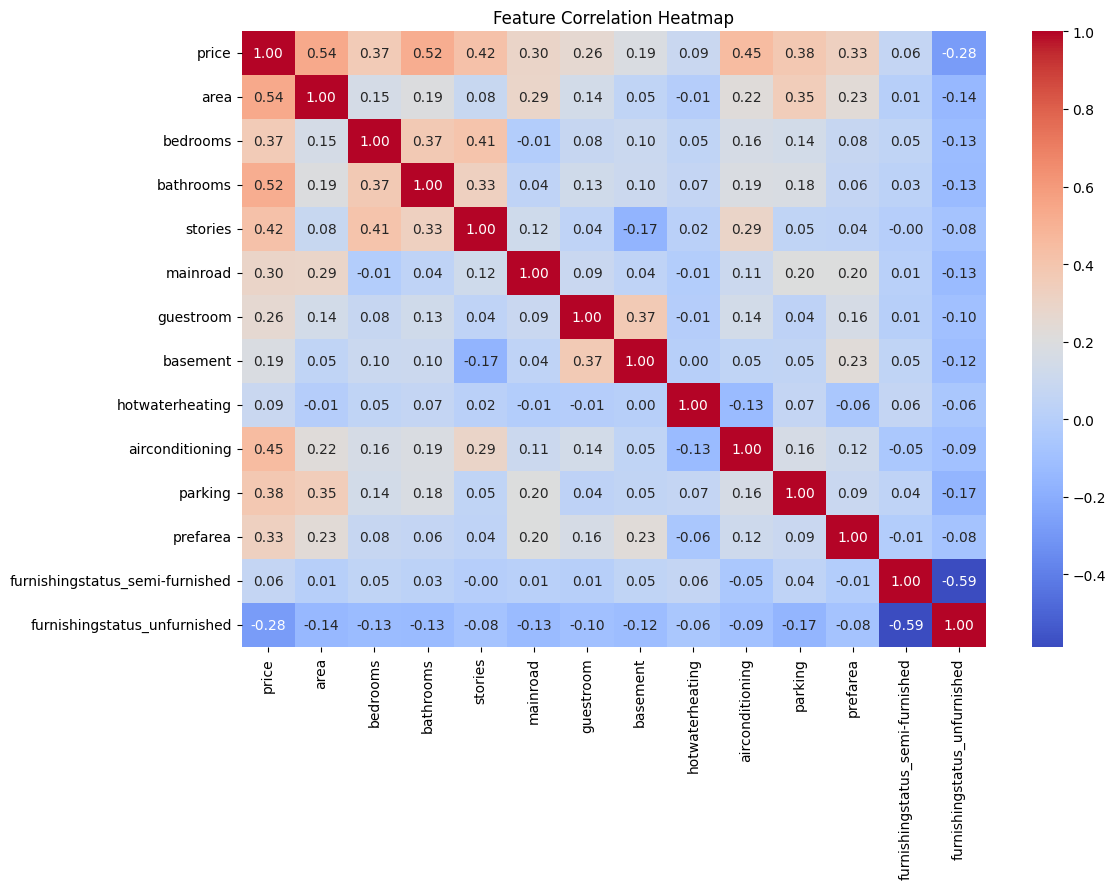

In [9]:
# Chart 2
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)
plt.savefig('correlation_map.png')
plt.title("Feature Correlation Heatmap")

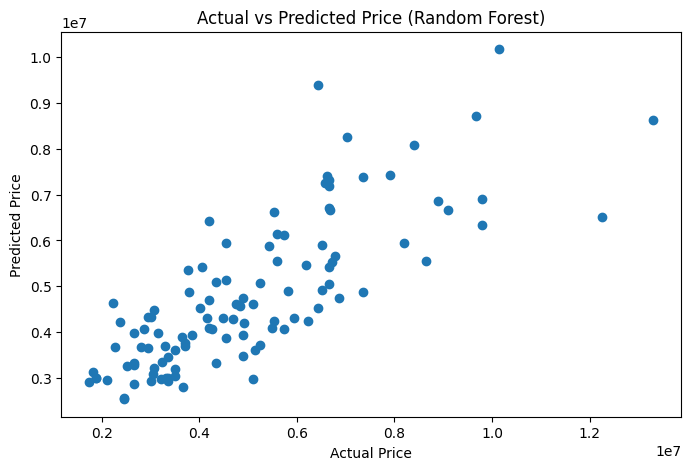

In [10]:
# Chart 3
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.savefig('actual_vs_predicted.png')
plt.show()


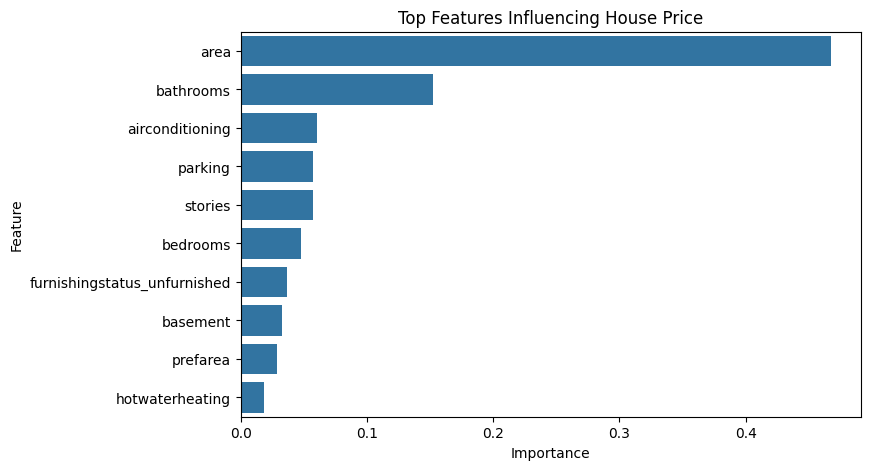

In [11]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title('Top Features Influencing House Price')
plt.savefig('feature_importance.png')
plt.show()


In [12]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[970043,1014947],
    'RMSE':[1324507,1399769],
    'R2':[0.653,0.612]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,970043,1324507,0.653
1,Random Forest,1014947,1399769,0.612


## Task 5 - Insights & Summary

1. Area, bathrooms, air conditioning, parking and preferred area are among the strongest factors affecting house prices.
2. In this dataset, Linear Regression achieved a higher R² score (0.653) than Random Forest (0.612), indicating better predictive performance. Because your actual results show Linear Regression performed better.
3. Larger houses with better facilities tend to have significantly higher prices.
4. Some features have a stronger influence than expected, especially location-related preferences.
5. The model can help real estate businesses estimate property values more accurately.
6. Businesses should focus on high-demand features to maximize property value.
